# Project: Liver Disease Classification
# Dataset: Dataset-620.csv

In [1]:
# @title EXPLORATORY DATA ANALYSIS (EDA)

# 1. IMPORT REQUIRED LIBRARIES
# pandas -> data handling
# numpy  -> numerical operations
# matplotlib & seaborn -> visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#2. LOAD THE DATASET
df = pd.read_csv("Dataset-620.csv", delimiter=';')
df

,category,age,sex,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase,protein
0,no_disease,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69
1,no_disease,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,no_disease,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,no_disease,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,no_disease,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,cirrhosis,62,f,32.0,416.6,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5
611,cirrhosis,64,f,24.0,102.8,2.9,44.4,20.0,1.54,3.02,63.0,35.9,71.3
612,cirrhosis,64,f,29.0,87.3,3.5,99.0,48.0,1.66,3.63,66.7,64.2,82
613,cirrhosis,46,f,33.0,NaN,39.0,62.0,20.0,3.56,4.20,52.0,50.0,71


In [3]:
df.head()

,category,age,sex,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase,protein
0,no_disease,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69
1,no_disease,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,no_disease,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,no_disease,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,no_disease,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [4]:
df.shape

(615, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   category                     615 non-null    object 
 1   age                          615 non-null    int64  
 2   sex                          615 non-null    object 
 3   albumin                      614 non-null    float64
 4   alkaline_phosphatase         597 non-null    float64
 5   alanine_aminotransferase     614 non-null    float64
 6   aspartate_aminotransferase   615 non-null    float64
 7   bilirubin                    615 non-null    float64
 8   cholinesterase               615 non-null    float64
 9   cholesterol                  605 non-null    float64
 10  creatinina                   615 non-null    float64
 11  gamma_glutamyl_transferase   615 non-null    float64
 12  protein                      615 non-null    object 
dtypes: float64(9), int64

In [6]:
df.describe()

,age,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase
count,615.000000,614.000000,597.000000,614.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000
mean,47.408130,41.620195,68.283920,28.450814,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171
std,10.055105,5.780629,26.028315,25.469689,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071
min,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000
25%,39.000000,38.800000,52.500000,16.400000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000
50%,47.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000
75%,54.000000,45.200000,80.100000,33.075000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000
max,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000


In [7]:
# 4. IDENTIFY TARGET VARIABLE
# The target variable is 'category'
# This represents liver disease stage (multi-class classification
df['category'].value_counts()

,count
category,
no_disease,533
cirrhosis,30
hepatitis,24
fibrosis,21
suspect_disease,7


In [8]:
df['category'].value_counts(normalize=True) * 100

,proportion
category,
no_disease,86.666667
cirrhosis,4.878049
hepatitis,3.902439
fibrosis,3.414634
suspect_disease,1.138211


In [9]:
# 5. IDENTIFY DATA TYPES
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols

Index(['category', 'sex', 'protein   '], dtype='object')

In [10]:
numerical_cols

Index(['age', 'albumin', 'alkaline_phosphatase', 'alanine_aminotransferase',
       'aspartate_aminotransferase', 'bilirubin', 'cholinesterase',
       'cholesterol', 'creatinina', 'gamma_glutamyl_transferase '],
      dtype='object')

In [11]:
# 6. MISSING VALUE ANALYSIS
df.isnull().sum()

,0
category,0
age,0
sex,0
albumin,1
alkaline_phosphatase,18
alanine_aminotransferase,1
aspartate_aminotransferase,0
bilirubin,0
cholinesterase,0
cholesterol,10


In [12]:
#REPLACE THE MISSING VALUES
mean_columns = [
    'albumin',
    'alkaline_phosphatase',
    'alanine_aminotransferase',
    'cholesterol'
]

for col in mean_columns:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipython-input-2864593045.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [13]:
df[mean_columns].isnull().sum()


,0
albumin,0
alkaline_phosphatase,0
alanine_aminotransferase,0
cholesterol,0


In [14]:
df.isnull().sum()

,0
category,0
age,0
sex,0
albumin,0
alkaline_phosphatase,0
alanine_aminotransferase,0
aspartate_aminotransferase,0
bilirubin,0
cholinesterase,0
cholesterol,0


In [15]:
(df.isnull().sum() / len(df)) * 100

,0
category,0.0
age,0.0
sex,0.0
albumin,0.0
alkaline_phosphatase,0.0
alanine_aminotransferase,0.0
aspartate_aminotransferase,0.0
bilirubin,0.0
cholinesterase,0.0
cholesterol,0.0


In [16]:
# 7. DUPLICATE RECORD CHECK
df.duplicated().sum()

np.int64(0)

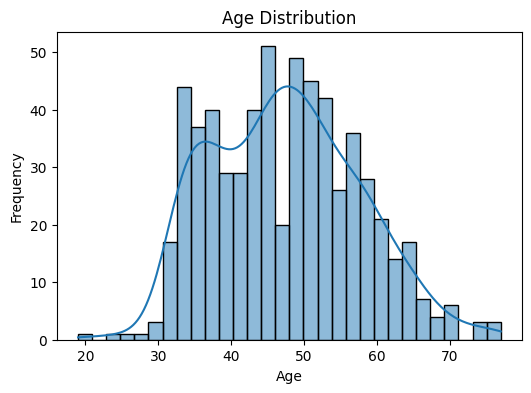

In [17]:
# 8. UNIVARIATE ANALYSIS
# Analyze distribution of individual features
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

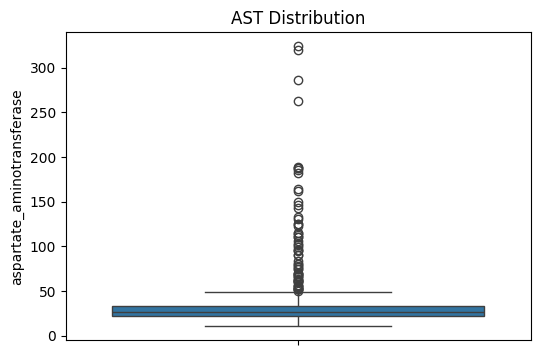

In [18]:
# 9. OUTLIER ANALYSIS
# Checking liver enzyme distributions
plt.figure(figsize=(6,4))
sns.boxplot(y=df['aspartate_aminotransferase'])
plt.title("AST Distribution")
plt.show()

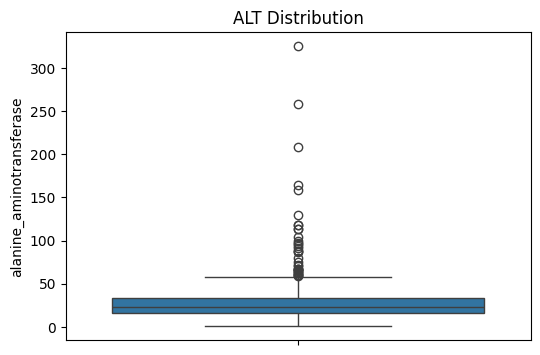

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['alanine_aminotransferase'])
plt.title("ALT Distribution")
plt.show()

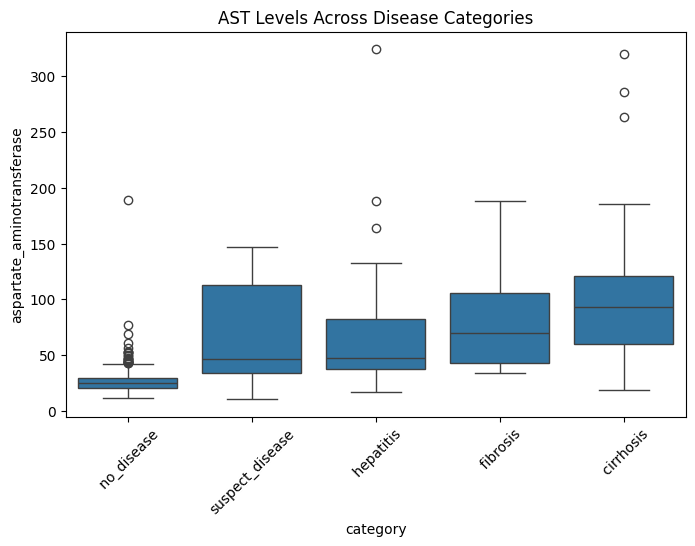

In [20]:
# 10. BIVARIATE ANALYSIS (FEATURE vs TARGET)
# Understanding how features change with disease category
# AST vs Disease Category
plt.figure(figsize=(8,5))
sns.boxplot(x='category', y='aspartate_aminotransferase', data=df)
plt.xticks(rotation=45)
plt.title("AST Levels Across Disease Categories")
plt.show()

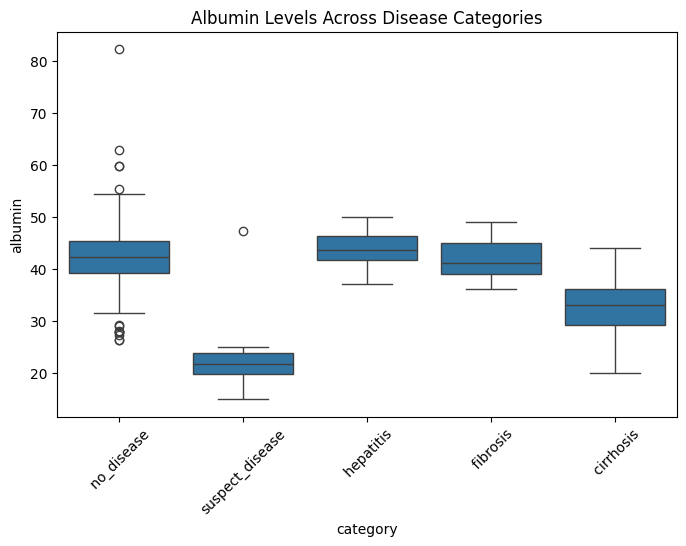

In [21]:
# Albumin vs Disease Category
plt.figure(figsize=(8,5))
sns.boxplot(x='category', y='albumin', data=df)
plt.xticks(rotation=45)
plt.title("Albumin Levels Across Disease Categories")
plt.show()

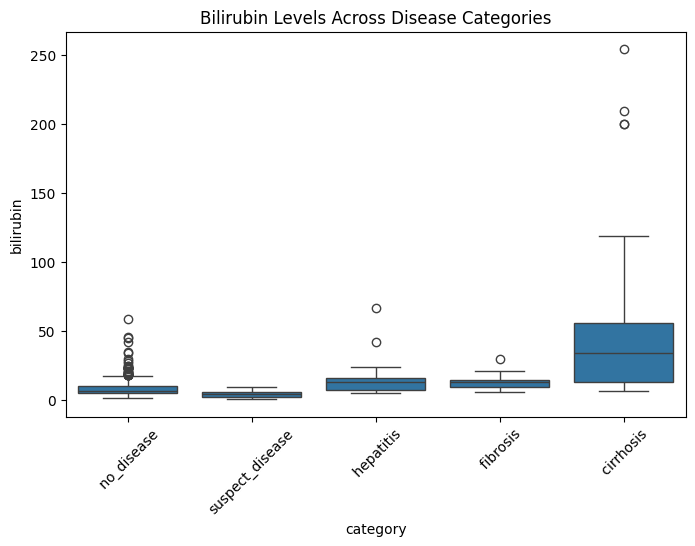

In [22]:
# Bilirubin vs Disease Category
plt.figure(figsize=(8,5))
sns.boxplot(x='category', y='bilirubin', data=df)
plt.xticks(rotation=45)
plt.title("Bilirubin Levels Across Disease Categories")
plt.show()

In [28]:
#12. CORRELATION ANALYSIS
# Compute correlation matrix
df[numerical_cols].corr()

,age,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase
age,1.000000,-0.197005,0.168473,-0.006017,0.088666,0.032492,-0.075093,0.123978,-0.022296,0.153087
albumin,-0.197005,1.000000,-0.138858,0.001606,-0.193397,-0.221650,0.375848,0.204803,-0.001573,-0.155555
alkaline_phosphatase,0.168473,-0.138858,1.000000,0.172461,0.062202,0.048600,0.032971,0.121914,0.149554,0.442262
alanine_aminotransferase,-0.006017,0.001606,0.172461,1.000000,0.273325,-0.038468,0.146953,0.068023,-0.043025,0.248086
aspartate_aminotransferase,0.088666,-0.193397,0.062202,0.273325,1.000000,0.312231,-0.208536,-0.207507,-0.021387,0.491263
bilirubin,0.032492,-0.221650,0.048600,-0.038468,0.312231,1.000000,-0.333172,-0.156261,0.031224,0.217024
cholinesterase,-0.075093,0.375848,0.032971,0.146953,-0.208536,-0.333172,1.000000,0.420163,-0.011157,-0.110345
cholesterol,0.123978,0.204803,0.121914,0.068023,-0.207507,-0.156261,0.420163,1.000000,-0.047667,-0.006828
creatinina,-0.022296,-0.001573,0.149554,-0.043025,-0.021387,0.031224,-0.011157,-0.047667,1.000000,0.121003
gamma_glutamyl_transferase,0.153087,-0.155555,0.442262,0.248086,0.491263,0.217024,-0.110345,-0.006828,0.121003,1.000000


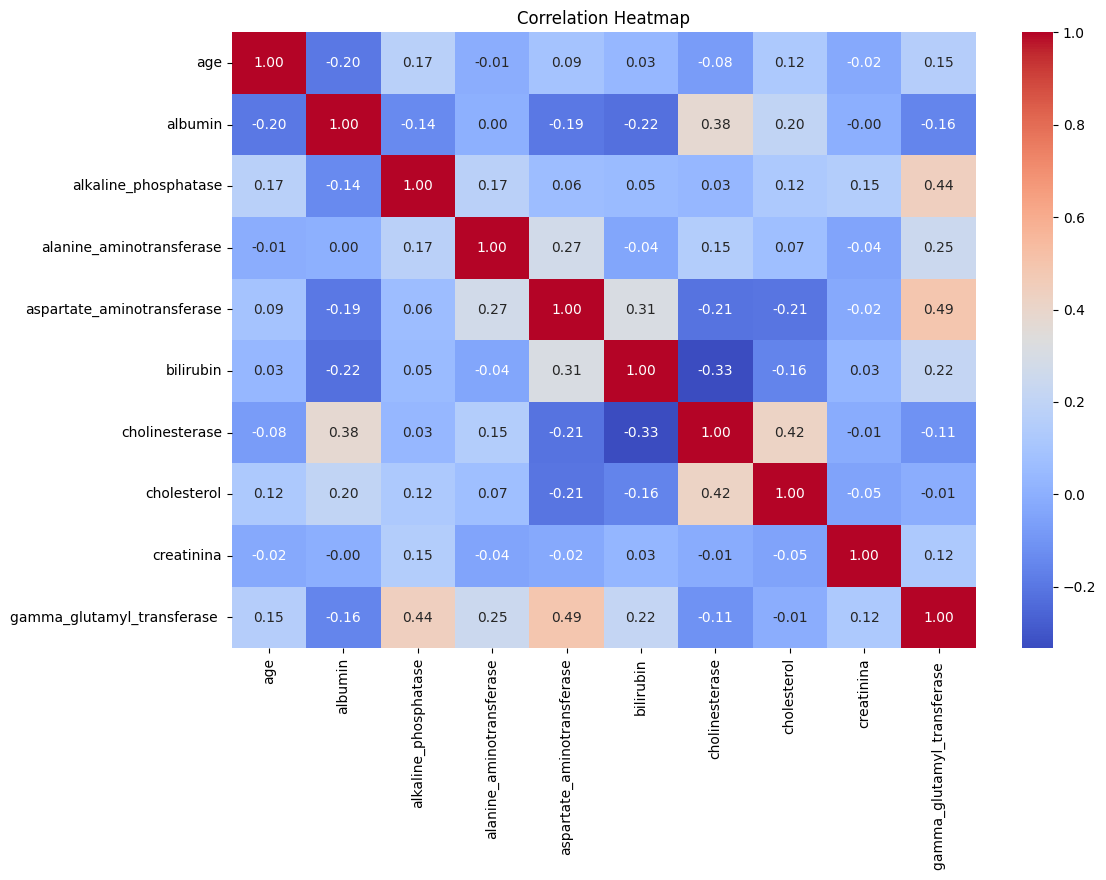

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df[numerical_cols].corr(),
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
#13. SCALING REQUIREMENT CHECK
df[numerical_cols].min()
df[numerical_cols].max()

,0
age,77.00
albumin,82.20
alkaline_phosphatase,416.60
alanine_aminotransferase,325.30
aspartate_aminotransferase,324.00
bilirubin,254.00
cholinesterase,16.41
cholesterol,9.67
creatinina,1079.10
gamma_glutamyl_transferase,650.90
